#Create a text-to-image generation pipeline using a pre-trained model like DALL-E.

Step 1: Install Dependencies

In [1]:
!pip install -q openai requests pillow

Step 2: FLUX.1-schnell model implementation

Initializing Enterprise-Grade Cloud API Pipeline...
Sending POST request to Cloud API: 'A futuristic agricultural drone watering a lush, vibrant tomato field. The drone is sleek and white with glowing blue accents. The scene is set during a golden hour sunset, cinematic lighting, photorealistic.'...
Waiting for server response...

✅ Success! Image generated.


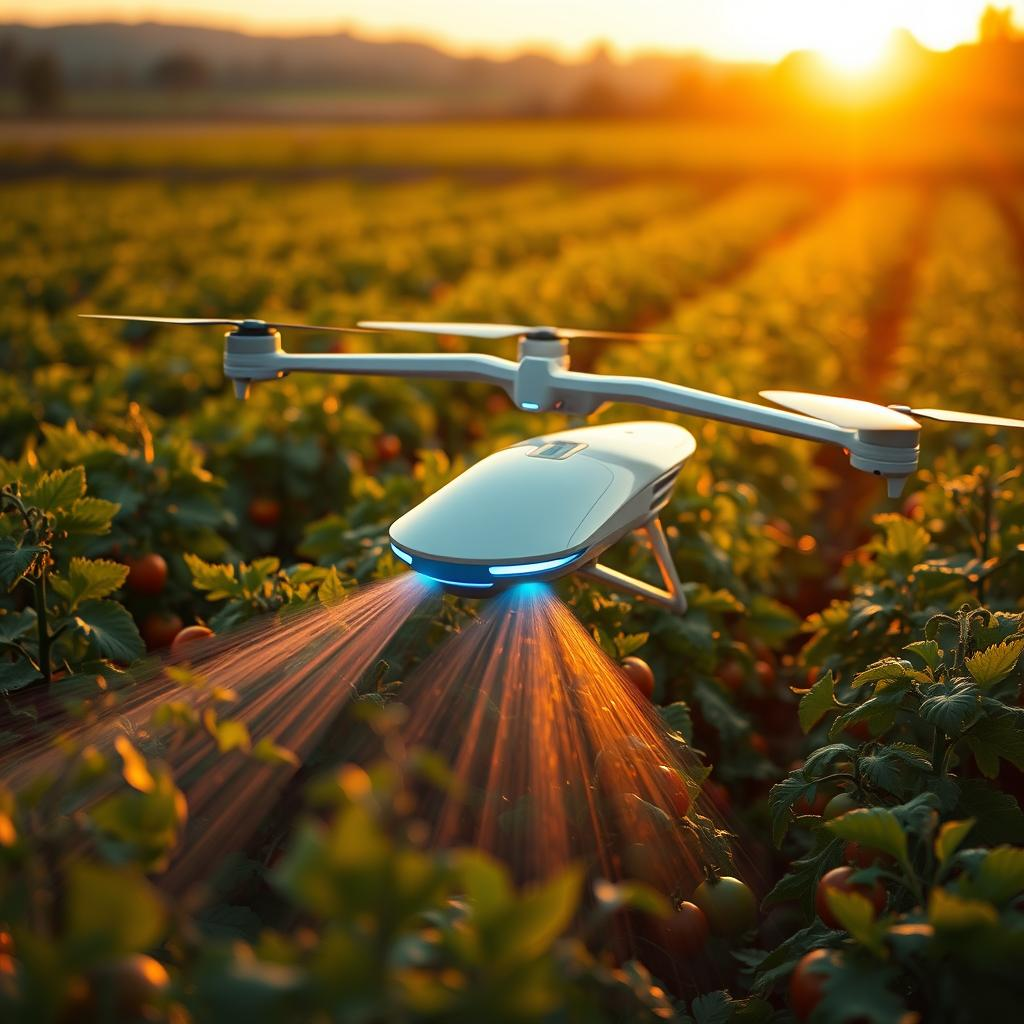

In [7]:
import requests
import io
from PIL import Image
from google.colab import userdata
from IPython.display import display

print("Initializing Enterprise-Grade Cloud API Pipeline...")

# 1. Securely load your token from Colab Secrets
hf_token = userdata.get('HF_TOKEN')
headers = {"Authorization": f"Bearer {hf_token}"}

# 2. UPDATED ENDPOINT: Using the new Hugging Face Router
API_URL = "https://router.huggingface.co/hf-inference/models/black-forest-labs/FLUX.1-schnell"

# 3. Define the creative prompt
prompt = (
    "A futuristic agricultural drone watering a lush, vibrant tomato field. "
    "The drone is sleek and white with glowing blue accents. "
    "The scene is set during a golden hour sunset, cinematic lighting, photorealistic."
)

print(f"Sending POST request to Cloud API: '{prompt}'...")
print("Waiting for server response...")

try:
    # 4. Execute the pipeline: Send the synchronous HTTP request
    response = requests.post(API_URL, headers=headers, json={"inputs": prompt})

    # Check if the server responded successfully (Status 200 = OK)
    if response.status_code == 200:
        print("\n✅ Success! Image generated.")

        # 5. Process the raw byte data into a viewable image
        image_bytes = response.content
        image = Image.open(io.BytesIO(image_bytes))

        # 6. Save and display
        output_filename = "api_pipeline_generation.png"
        image.save(output_filename)
        display(image)
    else:
        # If the server is asleep or overloaded, it will tell us here
        print(f"\n❌ API Error {response.status_code}: {response.text}")
        print("Tip: If you get a 503 error, the model is just waking up. Run the cell again in 10-20 seconds!")

except Exception as e:
    print(f"\nAn error occurred in the pipeline: {e}")